<a href="https://colab.research.google.com/github/dekenfebrianoo/data_analytics/blob/main/data_analytics_kel_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Import Libraries**

In [ ]:
# Melakukan import terhadap semua library yang dibutuhkan untuk melakukan EDA.
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Melakukan import data Kaggle guna untuk mendownload data
import kagglehub

path = kagglehub.dataset_download("thedevastator/unlock-profits-with-e-commerce-sales-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'unlock-profits-with-e-commerce-sales-data' dataset.
Path to dataset files: /kaggle/input/unlock-profits-with-e-commerce-sales-data


In [ ]:
# Melihat semua data CSV yang telah di import dari data Kaggle
import os

os.listdir(path)

['Amazon Sale Report.csv',
 'Cloud Warehouse Compersion Chart.csv',
 'May-2022.csv',
 'P  L March 2021.csv',
 'International sale Report.csv',
 'Expense IIGF.csv',
 'Sale Report.csv']

## **Data Loading**

In [ ]:
# Mendeklari path file CSV yang telah di download dan ditampung dengan variabel df
df = pd.read_csv(path + "/Amazon Sale Report.csv")

/tmp/ipykernel_2815/3421241701.py:2: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path + "/Amazon Sale Report.csv")


In [ ]:
df.head()
df.shape

(128975, 24)

## **Initial Data Profiling**

In [ ]:
# Melakukan summary terhadap DataFrame yang telah di read untuk mengecek adanya missing value dan mengecek kolom terhadap adanya kesalahan format
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  object 
 2   Date                128975 non-null  object 
 3   Status              128975 non-null  object 
 4   Fulfilment          128975 non-null  object 
 5   Sales Channel       128975 non-null  object 
 6   ship-service-level  128975 non-null  object 
 7   Style               128975 non-null  object 
 8   SKU                 128975 non-null  object 
 9   Category            128975 non-null  object 
 10  Size                128975 non-null  object 
 11  ASIN                128975 non-null  object 
 12  Courier Status      122103 non-null  object 
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  object 
 15  Amount              121180 non-nul

In [ ]:
# Problem : Data Duplication
# Melakukan penjumlahan pada kolom Order ID untuk mengetahui berapa banyak data yang terduplikasi
int(df["Order ID"].duplicated().sum())

8597

In [ ]:
# Solution : Remove Data Duplication
# Menghilangkan semua data duplikasi pada kolom ID
#df = df.drop_duplicates(subset=["Order ID"])

In [ ]:
# Result : Data Duplication Removed
# Melakukan penjumlahan pada kolom Order ID untuk mengecek apakah data duplikasi berhasil dihilangkan
int(df["Order ID"].duplicated().sum())

8597

## **Descriptive Statistics**

In [ ]:
# Menghasilkan ringkasan statistik deskriptif dari data yang terdapat di DataFrame.
df.describe()

,index,Qty,Amount,ship-postal-code
count,128975.000000,128975.000000,121180.000000,128942.000000
mean,64487.000000,0.904431,648.561465,463966.236509
std,37232.019822,0.313354,281.211687,191476.764941
min,0.000000,0.000000,0.000000,110001.000000
25%,32243.500000,1.000000,449.000000,382421.000000
50%,64487.000000,1.000000,605.000000,500033.000000
75%,96730.500000,1.000000,788.000000,600024.000000
max,128974.000000,15.000000,5584.000000,989898.000000


In [ ]:
# Date seharusnya bukan object (string) namun seharusnya datetime
df['Date'] = pd.to_datetime(df['Date'])

/tmp/ipykernel_2815/1822370615.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


In [ ]:
df['Date'].dtype

dtype('<M8[ns]')

In [ ]:
df['ship-postal-code'] = df['ship-postal-code'].astype(str)

In [ ]:
df['ship-postal-code'].dtype

dtype('O')

In [ ]:
df['Unnamed: 22'].unique()

array([nan, False], dtype=object)

In [ ]:
df.drop(columns=['Unnamed: 22'], inplace=True)

In [ ]:
# Mengecek berapa banyak null value pada data
df.isnull().sum()

,0
index,0
Order ID,0
Date,0
Status,0
Fulfilment,0
Sales Channel,0
ship-service-level,0
Style,0
SKU,0
Category,0


In [ ]:
df['Courier Status'] = df['Courier Status'].fillna('Not Shipped')

In [ ]:
df['ship-postal-code'] = df['ship-postal-code'].astype(str)

In [ ]:
df['currency'].value_counts()

,count
currency,
INR,121180


In [ ]:
df['currency'] = df['currency'].fillna('INR')

In [ ]:
df['Amount'] = df['Amount'].fillna(0)

In [ ]:
df = df.dropna(subset=['ship-city'])

In [ ]:
df = df.dropna(subset=['ship-state'])

In [ ]:
df = df.dropna(subset=['ship-country'])

In [ ]:
df = df.dropna(subset=['ship-postal-code'])

In [ ]:
df['promotion-ids'] = df['promotion-ids'].fillna('None')

In [ ]:
df['fulfilled-by'] = df['fulfilled-by'].fillna('Amazon')

In [ ]:
# Mengecek null value yang sudah dihilangkan pada data
df.isnull().sum()

,0
index,0
Order ID,0
Date,0
Status,0
Fulfilment,0
Sales Channel,0
ship-service-level,0
Style,0
SKU,0
Category,0


In [ ]:
# Mengecek semua index memiliki nilai yang unik dan terurut
df['index'].unique()

array([     0,      1,      2, ..., 128972, 128973, 128974])

In [ ]:
# Mengecek keunikan value pada kolom Order ID
df['Order ID'].unique()

array(['405-8078784-5731545', '171-9198151-1101146',
       '404-0687676-7273146', ..., '407-9547469-3152358',
       '402-6184140-0545956', '408-7436540-8728312'], dtype=object)

In [ ]:
df['Date'].unique()

<DatetimeArray>
['2022-04-30 00:00:00', '2022-04-29 00:00:00', '2022-04-28 00:00:00',
 '2022-04-27 00:00:00', '2022-04-26 00:00:00', '2022-04-25 00:00:00',
 '2022-04-24 00:00:00', '2022-04-23 00:00:00', '2022-04-22 00:00:00',
 '2022-04-21 00:00:00', '2022-04-20 00:00:00', '2022-04-19 00:00:00',
 '2022-04-18 00:00:00', '2022-04-17 00:00:00', '2022-04-16 00:00:00',
 '2022-04-15 00:00:00', '2022-04-14 00:00:00', '2022-04-13 00:00:00',
 '2022-04-12 00:00:00', '2022-04-11 00:00:00', '2022-04-10 00:00:00',
 '2022-04-09 00:00:00', '2022-04-08 00:00:00', '2022-04-07 00:00:00',
 '2022-04-06 00:00:00', '2022-04-05 00:00:00', '2022-04-04 00:00:00',
 '2022-04-03 00:00:00', '2022-04-02 00:00:00', '2022-04-01 00:00:00',
 '2022-03-31 00:00:00', '2022-05-31 00:00:00', '2022-05-30 00:00:00',
 '2022-05-29 00:00:00', '2022-05-28 00:00:00', '2022-05-27 00:00:00',
 '2022-05-26 00:00:00', '2022-05-25 00:00:00', '2022-05-24 00:00:00',
 '2022-05-23 00:00:00', '2022-05-22 00:00:00', '2022-05-21 00:00:00',
 '20

In [ ]:
df['Status'].unique()

array(['Cancelled', 'Shipped - Delivered to Buyer', 'Shipped',
       'Shipped - Returned to Seller', 'Shipped - Rejected by Buyer',
       'Shipped - Lost in Transit', 'Shipped - Out for Delivery',
       'Shipped - Returning to Seller', 'Shipped - Picked Up', 'Pending',
       'Pending - Waiting for Pick Up', 'Shipped - Damaged', 'Shipping'],
      dtype=object)

In [ ]:
df['Fulfilment'].unique()

array(['Merchant', 'Amazon'], dtype=object)

In [ ]:
df['SKU'].unique()

array(['SET389-KR-NP-S', 'JNE3781-KR-XXXL', 'JNE3371-KR-XL', ...,
       'JNE3370-KR-S', 'JNE3678-TU-XXL', 'SET045-KR-NP-M'], dtype=object)

In [ ]:
df['Amount'].unique()

array([ 647.62,  406.  ,  329.  , ...,  708.58, 1244.  ,  639.  ])

# Exploratory Analysis

In [ ]:
df['ship-city'].value_counts().head(5)

,count
ship-city,
BENGALURU,11217
HYDERABAD,8074
MUMBAI,6126
NEW DELHI,5795
CHENNAI,5421


In [ ]:
# Kesimpulan : Bengaluru paling sering beli

In [ ]:
df['ship-state'].value_counts().head(5)

,count
ship-state,
MAHARASHTRA,22260
KARNATAKA,17326
TAMIL NADU,11483
TELANGANA,11330
UTTAR PRADESH,10638


In [ ]:
# Kesimpulan : Maharashtra paling sering beli

In [ ]:
df.groupby('ship-state')['Amount'].sum().sort_values(ascending=False).head(5)

,Amount
ship-state,
MAHARASHTRA,13335534.14
KARNATAKA,10481114.37
TELANGANA,6916615.65
UTTAR PRADESH,6816642.08
TAMIL NADU,6515650.11


In [ ]:
# Kesimpulan : Paling tinggi revenue itu di city = BENGALURU

In [ ]:
df.groupby('ship-state')['Amount'].sum().sort_values(ascending=False).tail(10)

,Amount
ship-state,
Arunachal pradesh,602.0
orissa,597.0
Puducherry,568.0
Punjab/Mohali/Zirakpur,568.0
Pondicherry,529.0
rajsthan,521.0
AR,493.0
Rajsthan,443.0
PB,399.0


In [ ]:
df['ship-state'].unique()

array(['MAHARASHTRA', 'KARNATAKA', 'PUDUCHERRY', 'TAMIL NADU',
       'UTTAR PRADESH', 'CHANDIGARH', 'TELANGANA', 'ANDHRA PRADESH',
       'RAJASTHAN', 'DELHI', 'HARYANA', 'ASSAM', 'JHARKHAND',
       'CHHATTISGARH', 'ODISHA', 'KERALA', 'MADHYA PRADESH',
       'WEST BENGAL', 'NAGALAND', 'Gujarat', 'UTTARAKHAND', 'BIHAR',
       'JAMMU & KASHMIR', 'PUNJAB', 'HIMACHAL PRADESH',
       'ARUNACHAL PRADESH', 'MANIPUR', 'Goa', 'MEGHALAYA', 'GOA',
       'TRIPURA', 'LADAKH', 'DADRA AND NAGAR', 'SIKKIM', 'Delhi',
       'ANDAMAN & NICOBAR ', 'Punjab', 'Rajshthan', 'Manipur',
       'rajasthan', 'Odisha', 'NL', 'Bihar', 'MIZORAM', 'punjab',
       'New Delhi', 'Rajasthan', 'Punjab/Mohali/Zirakpur', 'Puducherry',
       'delhi', 'RJ', 'Chandigarh', 'orissa', 'LAKSHADWEEP', 'goa', 'PB',
       'APO', 'Arunachal Pradesh', 'AR', 'Pondicherry', 'Sikkim',
       'Arunachal pradesh', 'Nagaland', 'bihar', 'Mizoram', 'rajsthan',
       'Orissa', 'Rajsthan', 'Meghalaya'], dtype=object)

In [ ]:
# Samakan format dulu
df['ship-state'] = df['ship-state'].str.strip().str.upper()

# Mapping typo & variasi
state_mapping = {
    'GUJARAT': 'GUJARAT',
    'GOA': 'GOA',
    'DELHI': 'DELHI',
    'NEW DELHI': 'DELHI',
    'RAJSH THAN': 'RAJASTHAN',
    'RAJSH THAN': 'RAJASTHAN',
    'RAJSTHAN': 'RAJASTHAN',
    'RAJSH THAN': 'RAJASTHAN',
    'RJ': 'RAJASTHAN',
    'PUNJAB/MOHALI/ZIRAKPUR': 'PUNJAB',
    'PB': 'PUNJAB',
    'PUNJAB': 'PUNJAB',
    'ORISSA': 'ODISHA',
    'NL': 'NAGALAND',
    'AR': 'ARUNACHAL PRADESH',
    'ARUNACHAL PRADESH': 'ARUNACHAL PRADESH',
    'ARUNACHAL PRADESH ': 'ARUNACHAL PRADESH',
    'PONDICHERRY': 'PUDUCHERRY',
    'ANDAMAN & NICOBAR': 'ANDAMAN AND NICOBAR ISLANDS',
    'ANDAMAN & NICOBAR ': 'ANDAMAN AND NICOBAR ISLANDS',
    'DADRA AND NAGAR': 'DADRA AND NAGAR HAVELI',
    'APO': 'UNKNOWN'
}

df['ship-state'] = df['ship-state'].replace(state_mapping)

In [ ]:
df['ship-state'].unique()

array(['MAHARASHTRA', 'KARNATAKA', 'PUDUCHERRY', 'TAMIL NADU',
       'UTTAR PRADESH', 'CHANDIGARH', 'TELANGANA', 'ANDHRA PRADESH',
       'RAJASTHAN', 'DELHI', 'HARYANA', 'ASSAM', 'JHARKHAND',
       'CHHATTISGARH', 'ODISHA', 'KERALA', 'MADHYA PRADESH',
       'WEST BENGAL', 'NAGALAND', 'GUJARAT', 'UTTARAKHAND', 'BIHAR',
       'JAMMU & KASHMIR', 'PUNJAB', 'HIMACHAL PRADESH',
       'ARUNACHAL PRADESH', 'MANIPUR', 'GOA', 'MEGHALAYA', 'TRIPURA',
       'LADAKH', 'DADRA AND NAGAR HAVELI', 'SIKKIM',
       'ANDAMAN AND NICOBAR ISLANDS', 'RAJSHTHAN', 'MIZORAM',
       'LAKSHADWEEP', 'UNKNOWN'], dtype=object)

In [ ]:
df.groupby('ship-state')['Amount'].sum().sort_values(ascending=False).head(5)

,Amount
ship-state,
MAHARASHTRA,13335534.14
KARNATAKA,10481114.37
TELANGANA,6916615.65
UTTAR PRADESH,6816642.08
TAMIL NADU,6515650.11


In [ ]:
df.groupby('ship-state')['Amount'].sum().sort_values(ascending=False).tail(5)

,Amount
ship-state,
MIZORAM,41948.71
LADAKH,38388.43
LAKSHADWEEP,3175.29
RAJSHTHAN,1126.00
UNKNOWN,0.00


In [ ]:
df['ship-country'].unique()

array(['IN'], dtype=object)

In [ ]:
df['fulfilled-by'].unique()

array(['Easy Ship', 'Amazon'], dtype=object)

In [ ]:
print("Unique values for 'Sales Channel':")
display(df['Sales Channel '].unique())

Unique values for 'Sales Channel':


array(['Amazon.in', 'Non-Amazon'], dtype=object)

In [ ]:
import pandas as pd
import kagglehub
import os

path = kagglehub.dataset_download("thedevastator/unlock-profits-with-e-commerce-sales-data")

df = pd.read_csv(path + "/Amazon Sale Report.csv")

df = df.drop_duplicates(subset=["Order ID"])

df['Date'] = pd.to_datetime(df['Date'])

df['ship-postal-code'] = df['ship-postal-code'].astype(str)

df.drop(columns=['Unnamed: 22'], inplace=True)

df['Courier Status'] = df['Courier Status'].fillna('Not Shipped')
df['currency'] = df['currency'].fillna('INR')
df['Amount'] = df['Amount'].fillna(0)
df['promotion-ids'] = df['promotion-ids'].fillna('None')
df['fulfilled-by'] = df['fulfilled-by'].fillna('Amazon')

df = df.dropna(subset=['ship-city'])
df = df.dropna(subset=['ship-state'])
df = df.dropna(subset=['ship-country'])

state_mapping = {
    'GUJARAT': 'GUJARAT',
    'GOA': 'GOA',
    'DELHI': 'DELHI',
    'NEW DELHI': 'DELHI',
    'RAJSH THAN': 'RAJASTHAN',
    'RAJSTHAN': 'RAJASTHAN',
    'RJ': 'RAJASTHAN',
    'PUNJAB/MOHALI/ZIRAKPUR': 'PUNJAB',
    'PB': 'PUNJAB',
    'PUNJAB': 'PUNJAB',
    'ORISSA': 'ODISHA',
    'NL': 'NAGALAND',
    'AR': 'ARUNACHAL PRADESH',
    'ARUNACHAL PRADESH': 'ARUNACHAL PRADESH',
    'ARUNACHAL PRADESH ': 'ARUNACHAL PRADESH',
    'PONDICHERRY': 'PUDUCHERRY',
    'ANDAMAN & NICOBAR': 'ANDAMAN AND NICOBAR ISLANDS',
    'ANDAMAN & NICOBAR ': 'ANDAMAN AND NICOBAR ISLANDS',
    'DADRA AND NAGAR': 'DADRA AND NAGAR HAVELI',
    'APO': 'UNKNOWN'
}
df['ship-state'] = df['ship-state'].str.strip().str.upper()
df['ship-state'] = df['ship-state'].replace(state_mapping)

print("DataFrame 'df' has been re-initialized and cleaned.")

Using Colab cache for faster access to the 'unlock-profits-with-e-commerce-sales-data' dataset.


/tmp/ipykernel_2815/479073407.py:7: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path + "/Amazon Sale Report.csv")
/tmp/ipykernel_2815/479073407.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


DataFrame 'df' has been re-initialized and cleaned.


In [ ]:
print("Unique values for 'Sales Channel':")
display(df['Sales Channel '].unique())

Unique values for 'Sales Channel':


array(['Amazon.in', 'Non-Amazon'], dtype=object)

In [ ]:
print("Columns in DataFrame df:")
display(df.columns)

Columns in DataFrame df:


Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by'],
      dtype='object')

In [ ]:
print("Unique values for 'Category':")
display(df['Category'].unique())

Unique values for 'Category':


array(['Set', 'kurta', 'Western Dress', 'Top', 'Ethnic Dress', 'Bottom',
       'Saree', 'Blouse', 'Dupatta'], dtype=object)

In [ ]:
print("Unique values for 'Size':")
display(df['Size'].unique())

Unique values for 'Size':


array(['S', '3XL', 'XL', 'L', 'XXL', 'XS', '6XL', 'M', '4XL', '5XL',
       'Free'], dtype=object)

In [ ]:
df['promotion-ids'].isnull().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 120350 entries, 0 to 128974
Data columns (total 23 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   index               120350 non-null  int64         
 1   Order ID            120350 non-null  object        
 2   Date                120350 non-null  datetime64[ns]
 3   Status              120350 non-null  object        
 4   Fulfilment          120350 non-null  object        
 5   Sales Channel       120350 non-null  object        
 6   ship-service-level  120350 non-null  object        
 7   Style               120350 non-null  object        
 8   SKU                 120350 non-null  object        
 9   Category            120350 non-null  object        
 10  Size                120350 non-null  object        
 11  ASIN                120350 non-null  object        
 12  Courier Status      120350 non-null  object        
 13  Qty                 120350 non-nul

## Analyze Sales Trends Over Time

In [ ]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

print("Extracted Year, Month, and Day columns.")

Extracted Year, Month, and Day columns.


In [ ]:
daily_trends = df.groupby('Date').agg(
    total_sales=('Amount', 'sum'),
    number_of_orders=('Order ID', 'count')
).reset_index()

print("Calculated daily total sales and number of orders.")
display(daily_trends.head())

Calculated daily total sales and number of orders.


,Date,total_sales,number_of_orders
0,2022-03-31,95971.85,158
1,2022-04-01,799478.22,1363
2,2022-04-02,844514.53,1452
3,2022-04-03,936106.19,1565
4,2022-04-04,829206.37,1376


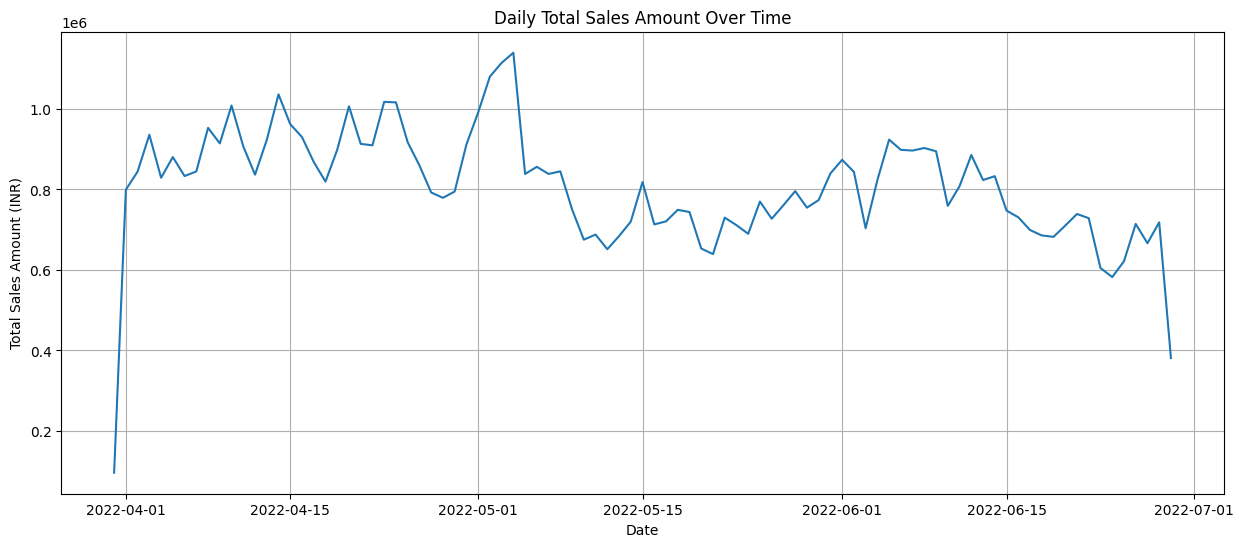

Generated line plot for daily total sales amount.


In [ ]:
plt.figure(figsize=(15, 6))
sns.lineplot(data=daily_trends, x='Date', y='total_sales')
plt.title('Daily Total Sales Amount Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales Amount (INR)')
plt.grid(True)
plt.show()

print("Generated line plot for daily total sales amount.")

## Visualize Top Categories


In [ ]:
category_trends = df.groupby('Category').agg(
    total_sales=('Amount', 'sum')
).reset_index()

print("Calculated total sales per category.")
display(category_trends.head())

Calculated total sales per category.


,Category,total_sales
0,Blouse,441243.52
1,Bottom,137821.96
2,Dupatta,305.00
3,Ethnic Dress,732525.61
4,Saree,107877.76


In [ ]:
top_categories_sales = category_trends.sort_values(by='total_sales', ascending=False).head(10)
print("Top 10 categories by total sales amount:")
display(top_categories_sales)

Top 10 categories by total sales amount:


,Category,total_sales
5,Set,36723981.86
8,kurta,19593905.16
7,Western Dress,10628239.72
6,Top,5029342.81
3,Ethnic Dress,732525.61
0,Blouse,441243.52
1,Bottom,137821.96
4,Saree,107877.76
2,Dupatta,305.00


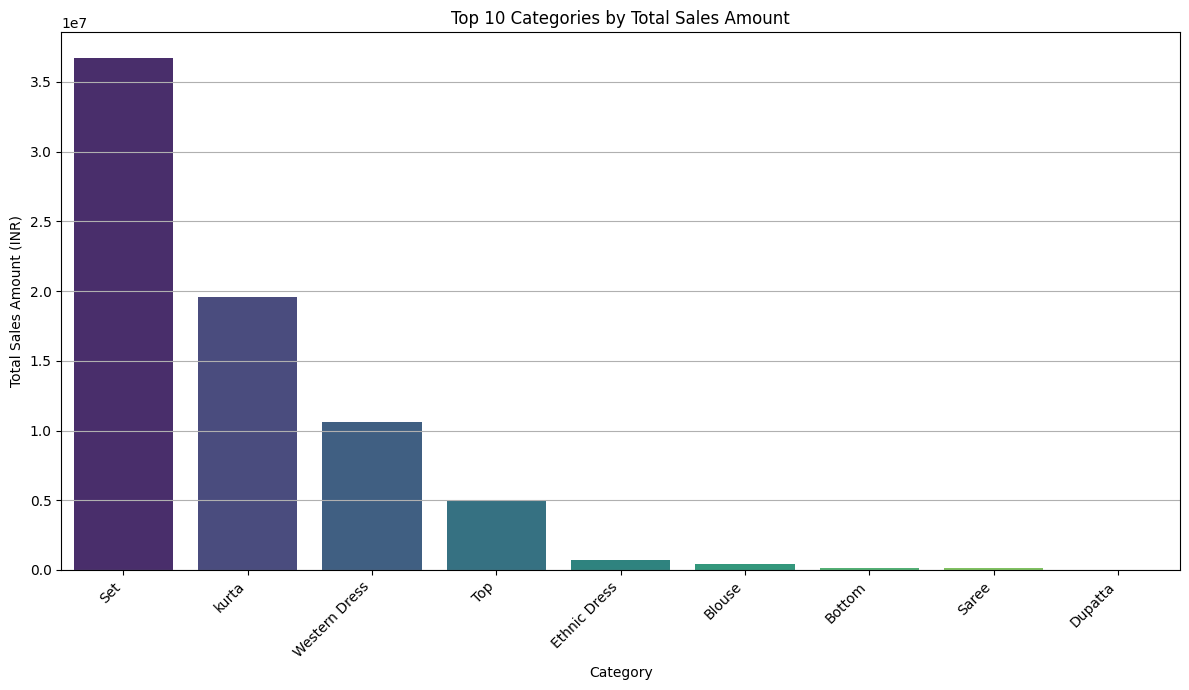

Generated bar chart for top 10 categories by total sales amount.


In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(data=top_categories_sales, x='Category', y='total_sales', hue='Category', palette='viridis', legend=False)
plt.title('Top 10 Categories by Total Sales Amount')
plt.xlabel('Category')
plt.ylabel('Total Sales Amount (INR)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

print("Generated bar chart for top 10 categories by total sales amount.")

## Explore Product Size Distribution


In [ ]:
size_distribution = df.groupby('Size').agg(
    total_sales=('Amount', 'sum')
).reset_index()

print("Calculated total sales per size:")
display(size_distribution.head())

Calculated total sales per size:


,Size,total_sales
0,3XL,8398875.08
1,4XL,303275.64
2,5XL,401883.15
3,6XL,524949.33
4,Free,186490.77


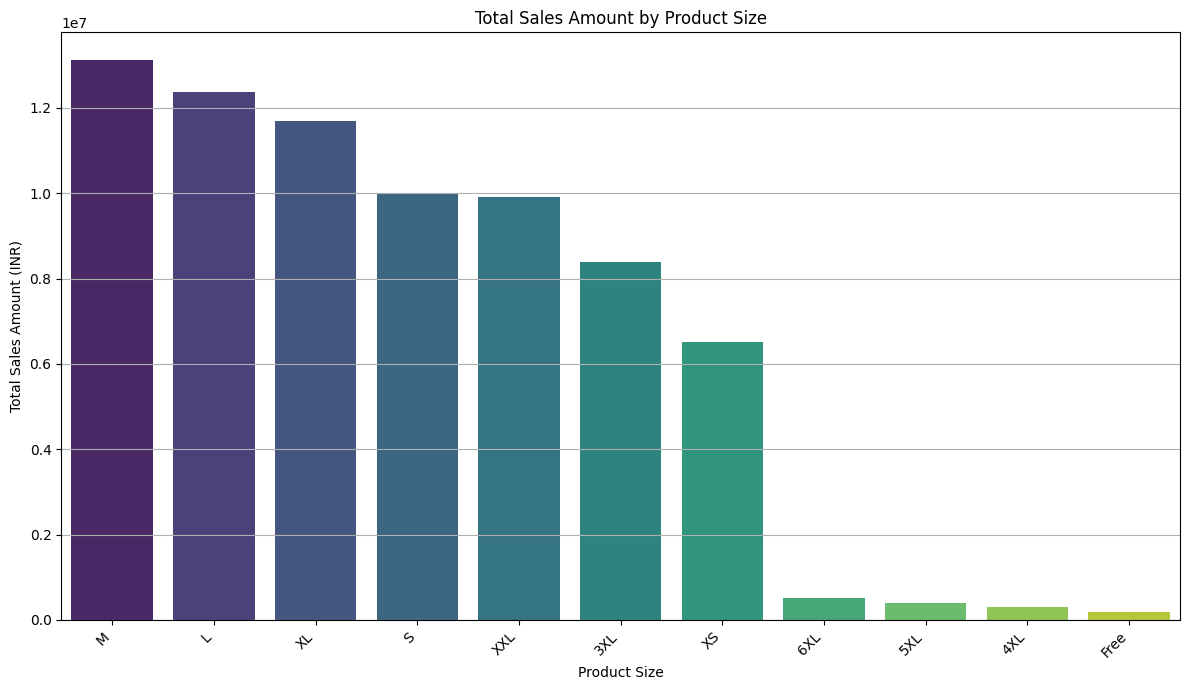

Generated bar chart for total sales amount by product size.


In [ ]:
plt.figure(figsize=(12, 7))
sns.barplot(data=size_distribution.sort_values(by='total_sales', ascending=False), x='Size', y='total_sales', hue='Size', palette='viridis', legend=False)
plt.title('Total Sales Amount by Product Size')
plt.xlabel('Product Size')
plt.ylabel('Total Sales Amount (INR)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

print("Generated bar chart for total sales amount by product size.")

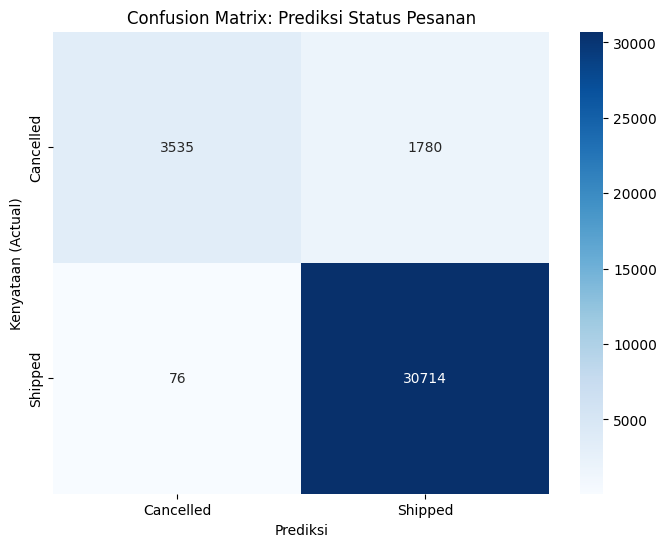

              precision    recall  f1-score   support

   Cancelled       0.98      0.67      0.79      5315
     Shipped       0.95      1.00      0.97     30790

    accuracy                           0.95     36105
   macro avg       0.96      0.83      0.88     36105
weighted avg       0.95      0.95      0.94     36105



In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

df['Status_Simple'] = df['Status'].apply(lambda x: 'Shipped' if 'Shipped' in x else 'Cancelled')

features = ['Category', 'Size', 'Amount', 'Qty']
data_model = df[features + ['Status_Simple']].dropna()

le = LabelEncoder()
for col in ['Category', 'Size']:
    data_model[col] = le.fit_transform(data_model[col])

X = data_model[features]
y = data_model['Status_Simple']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
labels = sorted(y_test.unique())

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Prediksi')
plt.ylabel('Kenyataan (Actual)')
plt.title('Confusion Matrix: Prediksi Status Pesanan')
plt.show()

print(classification_report(y_test, y_pred))

## **Decision Tree Classifier for Order Status Prediction**

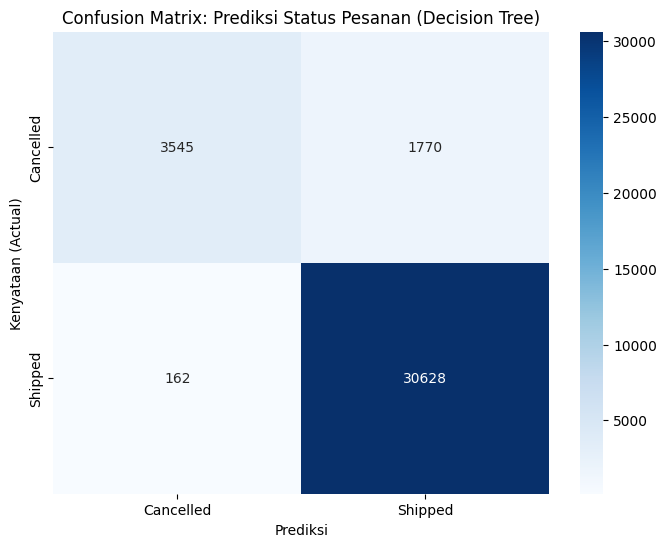

Classification Report for Decision Tree Classifier:
              precision    recall  f1-score   support

   Cancelled       0.96      0.67      0.79      5315
     Shipped       0.95      0.99      0.97     30790

    accuracy                           0.95     36105
   macro avg       0.95      0.83      0.88     36105
weighted avg       0.95      0.95      0.94     36105



In [ ]:
from sklearn.tree import DecisionTreeClassifier

model_dtree = DecisionTreeClassifier(random_state=42)
model_dtree.fit(X_train, y_train)

y_pred_dtree = model_dtree.predict(X_test)

cm_dtree = confusion_matrix(y_test, y_pred_dtree)
labels_dtree = sorted(y_test.unique())

plt.figure(figsize=(8, 6))
sns.heatmap(cm_dtree, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_dtree, yticklabels=labels_dtree)
plt.xlabel('Prediksi')
plt.ylabel('Kenyataan (Actual)')
plt.title('Confusion Matrix: Prediksi Status Pesanan (Decision Tree)')
plt.show()

print("Classification Report for Decision Tree Classifier:")
print(classification_report(y_test, y_pred_dtree))

## **Logistic Regression for Order Status Prediction**

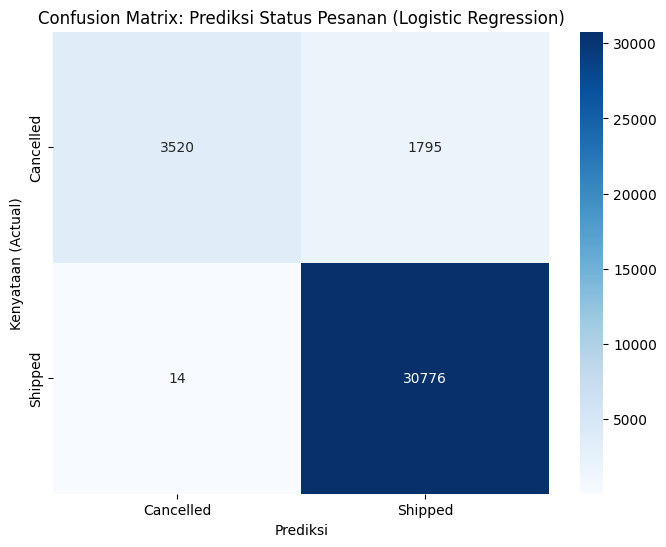

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

   Cancelled       1.00      0.66      0.80      5315
     Shipped       0.94      1.00      0.97     30790

    accuracy                           0.95     36105
   macro avg       0.97      0.83      0.88     36105
weighted avg       0.95      0.95      0.95     36105



In [ ]:
from sklearn.linear_model import LogisticRegression

model_logistic = LogisticRegression(solver='liblinear', random_state=42, max_iter=200)
model_logistic.fit(X_train, y_train)

y_pred_logistic = model_logistic.predict(X_test)

cm_logistic = confusion_matrix(y_test, y_pred_logistic)
labels_logistic = sorted(y_test.unique())

plt.figure(figsize=(8, 6))
sns.heatmap(cm_logistic, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_logistic, yticklabels=labels_logistic)
plt.xlabel('Prediksi')
plt.ylabel('Kenyataan (Actual)')
plt.title('Confusion Matrix: Prediksi Status Pesanan (Logistic Regression)')
plt.show()

print("Classification Report for Logistic Regression:")
print(classification_report(y_test, y_pred_logistic))

## **Additional Evaluation Metrics**

### **ROC AUC Score for Classification Models**

In [ ]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder

le_y = LabelEncoder()
y_test_encoded = le_y.fit_transform(y_test)

if 'Shipped' in le_y.classes_ and le_y.classes_[1] == 'Shipped':
    y_proba_rf = model.predict_proba(X_test)[:, 1]
else:
    y_proba_rf = model.predict_proba(X_test)[:, 0]

roc_auc_rf = roc_auc_score(y_test_encoded, y_proba_rf)
print(f"ROC AUC Score for Random Forest Classifier: {roc_auc_rf:.2f}")

if 'Shipped' in le_y.classes_ and le_y.classes_[1] == 'Shipped':
    y_proba_dtree = model_dtree.predict_proba(X_test)[:, 1]
else:
    y_proba_dtree = model_dtree.predict_proba(X_test)[:, 0]

roc_auc_dtree = roc_auc_score(y_test_encoded, y_proba_dtree)
print(f"ROC AUC Score for Decision Tree Classifier: {roc_auc_dtree:.2f}")

if 'Shipped' in le_y.classes_ and le_y.classes_[1] == 'Shipped':
    y_proba_logistic = model_logistic.predict_proba(X_test)[:, 1]
else:
    y_proba_logistic = model_logistic.predict_proba(X_test)[:, 0]

roc_auc_logistic = roc_auc_score(y_test_encoded, y_proba_logistic)
print(f"ROC AUC Score for Logistic Regression: {roc_auc_logistic:.2f}")

ROC AUC Score for Random Forest Classifier: 0.85
ROC AUC Score for Decision Tree Classifier: 0.85
ROC AUC Score for Logistic Regression: 0.84
